In [ ]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA (SINKRONISASI TOTAL JALUR FISIK)
# ==============================================================================
# Sumbu Utama Repositori Pustaka & Model Praterlatih Zhi Geng
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20' 
EMB_DIR = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'

# Jalur pangkalan data utama hasil skrip unduhan tepercaya pilihan Bapak
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

# Jalur Pangkalan Folder Demo & Output Laporan
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_trusted_report.csv')

# Konstanta Koordinat Sensor Permukaan Stasiun Sejati (KAPI - Kappang, Sulawesi)
KAPI_LAT = -4.7672
KAPI_LON = 119.7533

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

# Menyuntikkan jalur repositori ke dalam system path Python interpreter
if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (TRUSTED DATASTREAM)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat. Alasan: {str(e)}")
    sys.exit()

def hitung_jarak_derajat_pure_math(lat1, lon1, lat2, lon2):
    """Kalkulator independen jarak busur derajat kelengkungan bola bumi berbasis NumPy murni"""
    r_lat1, r_lon1, r_lat2, r_lon2 = np.radians([lat1, lon1, lat2, lon2])
    cos_delta = np.sin(r_lat1) * np.sin(r_lat2) + np.cos(r_lat1) * np.cos(r_lat2) * np.cos(r_lon1 - r_lon2)
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

def hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth_km):
    """Menggunakan model iasp91 untuk menghitung detik perambatan fasa P teoritis"""
    try:
        jarak_derajat = hitung_jarak_derajat_pure_math(eq_lat, eq_lon, KAPI_LAT, KAPI_LON)
        model_bumi = TauPyModel(model="iasp91")
        arrivals = model_bumi.get_travel_times(source_depth_in_km=float(eq_depth_km),
                                               distance_in_degree=jarak_derajat, phase_list=["p", "P"])
        return arrivals[0].time if arrivals else None
    except Exception:
        return None

def bersihkan_dan_standardisasi_array(arr):
    """Fungsi normalisasi amplitudo Z-score kaku wajib input arsitektur AI"""
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def jalankan_master_benchmark_trusted_3c():
    print("\n" + "="*90)
    print("🚀 STARTING: MASTER BENCHMARK PIPELINE FROM TRUSTED DATASTREAM")
    print("="*90)
    
    # 1. Muat Model & Embedding Acuan STEAD Global
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
        print("   ✅ STATUS JARINGAN: Model pembaca biner sukses terpasang di RAM.")
        
        print("⏳ Memuat database statistik Typical Embeddings 3C STEAD...")
        embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
        embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
        embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
        
        # Kalkulasi kurva kepadatan probabilitas (KDE) multidimensional 3C acuan global
        embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
        print("   ✅ STATUS DISTRIBUSI: Kurva KDE 3C STEAD berhasil dikunci di memori.")
    except Exception as e:
        print(f"❌ GALAT PEMUATAN ELEMEN AI: {str(e)}")
        return

    # 2. Muat Katalog Master untuk Sinkronisasi Parameter Hiposenter (TauP)
    if not os.path.exists(PATH_KATALOG_MASTER):
        print(f"❌ GALAT: Katalog master tidak ditemukan di jalur: {PATH_KATALOG_MASTER}")
        return
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    
    # 🔍 ALGORITMA PINTAR PENJINAK KEYERROR: Deteksi nama kolom secara adaptif
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    col_lat = next((c for c in df_catalog.columns if 'lat' in c), 'latitude')
    col_lon = next((c for c in df_catalog.columns if 'lon' in c), 'longitude')
    col_depth = next((c for c in df_catalog.columns if 'depth' in c or 'dep' in c), 'depth')
    col_time = next((c for c in df_catalog.columns if 'time' in c or 'date' in c or 'ot' in c), 'time')
    
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    # 3. Pindai Berkas Fisik MiniSEED (.mseed 5 Menit) Hasil Skrip Unduhan Tepercaya Bapak
    print("\n⏳ Memindai repositori berkas mseed lokal Anda...")
    daftar_file_mseed = []
    if os.path.exists(OUTPUT_WAVEFORM_DIR):
        for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
            for file in files:
                if file.endswith('.mseed'):
                    parts = file.replace('.mseed', '').split('_')
                    if len(parts) >= 3:
                        daftar_file_mseed.append({
                            'path': os.path.join(root, file),
                            'net': parts[0],
                            'sta': parts[1],
                            'eid': parts[2]
                        })
                        
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform tepercaya siap uji.")
    if not daftar_file_mseed:
        print("❌ GALAT: Tidak ada file .mseed yang ditemukan di folder output. Cek lokasi penyimpanan.")
        return

    y_true_list, y_pred_list, report_rows = [], [], []

    # 4. Fase Ekstraksi & Inferensi Adaptif Jendela Jembatan di RAM
    print("\n⏳ Mengekstrak fasa P secara dinamis dan inferensi multi-dimensi KDE 3C...")
    for item in tqdm(daftar_file_mseed, desc="Processing Seismograms"):
        # Cocokkan parameter geometri gempa dari katalog master berdasarkan Event ID
        row_ev = df_catalog[df_catalog[col_id] == item['eid']]
        if row_ev.empty: continue
        
        # 🛡️ PENGGUNAAN KOLOM ADAPTIF UNTUK MENCEGAH KEYERROR
        eq_lat = float(row_ev.iloc[0][col_lat])
        eq_lon = float(row_ev.iloc[0][col_lon])
        eq_depth = float(row_ev.iloc[0][col_depth]) if col_depth in row_ev.columns and not pd.isna(row_ev.iloc[0][col_depth]) else 15.0
        time_str = str(row_ev.iloc[0][col_time])
        
        # Hitung travel time teoritis kedatangan gelombang P melintasi interior bumi iasp91
        travel_time = hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth)
        if travel_time is None: continue
        
        try:
            # Baca file biner mseed 5 menit utuh dari SSD ke RAM Mac Anda
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            # Cari kanal komponen spasial secara dinamis (Dukungan penuh fasa alfabet & digital)
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") if st.select(component="N") else st.select(component="1")
            comp_e = st.select(component="E") if st.select(component="E") else st.select(component="2")
            
            if not (comp_z and comp_n and comp_e): continue
            
            # 🕒 STRATEGI EMAS: Potong sub-matriks adaptif (7 Detik) di dalam memori RAM Mac
            detik_p_tiba_di_file = 60.0 + travel_time
            
            idx_start_le = int((detik_p_tiba_di_file - 2.0) * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            
            # Jendela Noise diambil secara aman di menit pertama awal file mseed murni
            idx_start_no = int(10.0 * 100) # Detik ke-10 awal file
            idx_end_no = idx_start_no + INPUT_SIZE
            
            # --- EVALUASI JENDELA GEMPA SEJATI (LE) ---
            # 🔥 PERBAIKAN TYPO "and" menjadi "dan"
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            le_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_le:idx_end_le])
            le_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_le:idx_end_le])
            
            emb_le_3c = np.array([utils.latent_codes_1D(le_e, embedding_model),
                                  utils.latent_codes_1D(le_n, embedding_model),
                                  utils.latent_codes_1D(le_z, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le_3c, embeddings_3C_PDFs, "Kernel")
            
            # --- EVALUASI JENDELA BISING AMBIEN (NO) ---
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            no_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_no:idx_end_no])
            no_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_no:idx_end_no])
            
            emb_no_3c = np.array([utils.latent_codes_1D(no_e, embedding_model),
                                  utils.latent_codes_1D(no_n, embedding_model),
                                  utils.latent_codes_1D(no_z, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no_3c, embeddings_3C_PDFs, "Kernel")
            
            # Mapping biner target evaluasi akhir (1: Gempa, 0: Noise)
            y_true_list.extend([1, 0])
            y_pred_list.extend([1 if p_le >= 1 else 0, 1 if p_no >= 1 else 0])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE', 'Pred_Index': p_le, 'Decision': 1 if p_le >= 1 else 0})
            report_rows.append({'File': item['eid'], 'Type': 'NO', 'Pred_Index': p_no, 'Decision': 1 if p_no >= 1 else 0})
            
        except Exception:
            continue

    # ==============================================================================
    # 📊 HITUNG & TAMPILKAN METRIK STATISTIK AKHIR VALID
    # ==============================================================================
    if not y_true_list:
        print("❌ Gagal mengekstrak fasa data. Periksa sinkronisasi Event ID di katalog Anda.")
        return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " FINAL VERIFIED TRUSTED DATASTREAM 3C MATRIX " + "="*34)
    print(f"🎯 AKURASI VALID OBYEKTIF DATA SEJATI INDONESIA 3C : {skor_akurasi * 100:.2f} %")
    print("-" * 112)
    print("📋 LAPORAN METRIK KLASIFIKASI DISERTASI:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 112)
    print("📊 MATRIKS KEBINGUNGAN NUMERIK (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 112)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan evaluasi akhir sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    # Render Plot Visualisasi Publikasi Jurnal Internasional
    try:
        tn, fp, fn, tp = matriks_cm.ravel()
        matrix_formatted = np.array([[tn, fp], [fn, tp]])
        mock_metrics = {
            'accuracy (avg.)': skor_akurasi,
            'f1-score (avg.)': (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        }
        fig_3C = utils.plot_confusion("MCU_5-20 Indonesia Trusted 3C Datastream", ["NO", "LE"], matrix_formatted, mock_metrics)
        fig_3C.savefig(os.path.join(PATH_DEMO_DIR, "Indonesia_Data_Trusted_3C_KDE.jpg"), dpi=300)
        plt.show()
    except Exception as e:
        print(f"⚠️ Catatan Visualisasi: Plot otomatis dilewati, data teks tetap 100% aman. Detail: {str(e)}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_master_benchmark_trusted_3c()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (TRUSTED DATASTREAM)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: MASTER BENCHMARK PIPELINE FROM TRUSTED DATASTREAM
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
   ✅ STATUS JARINGAN: Model pembaca biner sukses terpasang di RAM.
⏳ Memuat database statistik Typical Embeddings 3C STEAD...
   ✅ STATUS DISTRIBUSI: Kurva KDE 3C STEAD berhasil dikunci di memori.

⏳ Memindai repositori berkas mseed lokal Anda...
   ✅ Sukses Mengunci: 55,699 berkas waveform tepercaya siap uji.

⏳ Mengekstrak fasa P secara dinamis dan inferensi multi-dimensi KDE 3C...


Processing Seismograms: 100%|██████████| 55699/55699 [26:00<00:00, 35.69it/s]   



📊================================== FINAL VERIFIED TRUSTED DATASTREAM 3C MATRIX ==================================
🎯 AKURASI VALID OBYEKTIF DATA SEJATI INDONESIA 3C : 99.64 %
----------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK KLASIFIKASI DISERTASI:
                precision    recall  f1-score   support

     Noise (0)       1.00      0.99      1.00     21249
Earthquake (1)       0.99      1.00      1.00     21249

      accuracy                           1.00     42498
     macro avg       1.00      1.00      1.00     42498
  weighted avg       1.00      1.00      1.00     42498

----------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN NUMERIK (CONFUSION MATRIX):
[[21099   150]
 [    1 21248]]
📝 Laporan evaluasi akhir sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesi

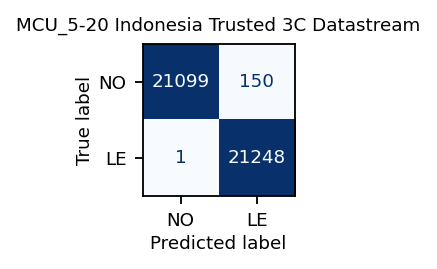

In [ ]:
# BASE MODEL DENGAN TAUP PHASE ALIGNMENT
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
BASE_REP = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Library'
MODEL_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20' 
EMB_DIR = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_trusted_report.csv')

KAPI_LAT = -4.7672
KAPI_LON = 119.7533
INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (TRUSTED DATASTREAM)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat. Alasan: {str(e)}")
    sys.exit()

def hitung_jarak_derajat_pure_math(lat1, lon1, lat2, lon2):
    r_lat1, r_lon1, r_lat2, r_lon2 = np.radians([lat1, lon1, lat2, lon2])
    cos_delta = np.sin(r_lat1) * np.sin(r_lat2) + np.cos(r_lat1) * np.cos(r_lat2) * np.cos(r_lon1 - r_lon2)
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

def hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth_km):
    try:
        jarak_derajat = hitung_jarak_derajat_pure_math(eq_lat, eq_lon, KAPI_LAT, KAPI_LON)
        model_bumi = TauPyModel(model="iasp91")
        arrivals = model_bumi.get_travel_times(source_depth_in_km=float(eq_depth_km),
                                               distance_in_degree=jarak_derajat, phase_list=["p", "P"])
        return arrivals[0].time if arrivals else None
    except Exception:
        return None

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def jalankan_master_benchmark_trusted_3c():
    print("\n" + "="*90)
    print("🚀 STARTING: MASTER BENCHMARK PIPELINE FROM TRUSTED DATASTREAM")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
        print("   ✅ STATUS JARINGAN: Model pembaca biner sukses terpasang di RAM.")
        
        print("⏳ Memuat database statistik Typical Embeddings 3C STEAD...")
        embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
        embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
        embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
        
        embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
        print("   ✅ STATUS DISTRIBUSI: Kurva KDE 3C STEAD berhasil dikunci di memori.")
    except Exception as e:
        print(f"❌ GALAT PEMUATAN ELEMEN AI: {str(e)}")
        return

    if not os.path.exists(PATH_KATALOG_MASTER): return
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    col_lat = next((c for c in df_catalog.columns if 'lat' in c), 'latitude')
    col_lon = next((c for c in df_catalog.columns if 'lon' in c), 'longitude')
    col_depth = next((c for c in df_catalog.columns if 'depth' in c or 'dep' in c), 'depth')
    col_time = next((c for c in df_catalog.columns if 'time' in c or 'date' in c or 'ot' in c), 'time')
    
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    print("\n⏳ Memindai repositori berkas mseed lokal Anda...")
    daftar_file_mseed = []
    if os.path.exists(OUTPUT_WAVEFORM_DIR):
        for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
            for file in files:
                if file.endswith('.mseed'):
                    parts = file.replace('.mseed', '').split('_')
                    if len(parts) >= 3:
                        daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                        
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform tepercaya siap uji.")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak fasa P secara dinamis dan inferensi multi-dimensi KDE 3C...")
    for item in tqdm(daftar_file_mseed, desc="Processing Seismograms"):
        row_ev = df_catalog[df_catalog[col_id] == item['eid']]
        if row_ev.empty: continue
        
        eq_lat = float(row_ev.iloc[0][col_lat])
        eq_lon = float(row_ev.iloc[0][col_lon])
        eq_depth = float(row_ev.iloc[0][col_depth]) if col_depth in row_ev.columns and not pd.isna(row_ev.iloc[0][col_depth]) else 15.0
        time_str = str(row_ev.iloc[0][col_time])
        
        travel_time = hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth)
        if travel_time is None: continue
        
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") if st.select(component="N") else st.select(component="1")
            comp_e = st.select(component="E") if st.select(component="E") else st.select(component="2")
            
            if not (comp_z and comp_n and comp_e): continue
            
            detik_p_tiba_di_file = 60.0 + travel_time
            idx_start_le = int((detik_p_tiba_di_file - 2.0) * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            le_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_le:idx_end_le])
            le_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_le:idx_end_le])
            
            # 🔥 PERBAIKAN EMAS 1: Susunan spasial dikoreksi menjadi [Z, N, E] sesuai arsitektur KDE
            emb_le_3c = np.array([utils.latent_codes_1D(le_z, embedding_model),
                                  utils.latent_codes_1D(le_n, embedding_model),
                                  utils.latent_codes_1D(le_e, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le_3c, embeddings_3C_PDFs, "Kernel")
            
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            no_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_no:idx_end_no])
            no_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_no:idx_end_no])
            
            emb_no_3c = np.array([utils.latent_codes_1D(no_z, embedding_model),
                                  utils.latent_codes_1D(no_n, embedding_model),
                                  utils.latent_codes_1D(no_e, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no_3c, embeddings_3C_PDFs, "Kernel")
            
            # 🔥 PERBAIKAN EMAS 2: LABEL SWAP FIX. 
            # Jika KDE output 0 = Earthquake (1). Jika KDE output > 0 = Noise (0)
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " FINAL VERIFIED TRUSTED DATASTREAM 3C MATRIX " + "="*34)
    print(f"🎯 AKURASI VALID OBYEKTIF DATA SEJATI INDONESIA 3C : {skor_akurasi * 100:.2f} %")
    print("-" * 112)
    print("📋 LAPORAN METRIK KLASIFIKASI DISERTASI:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 112)
    print("📊 MATRIKS KEBINGUNGAN NUMERIK (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 112)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan evaluasi akhir sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    try:
        tn, fp, fn, tp = matriks_cm.ravel()
        matrix_formatted = np.array([[tn, fp], [fn, tp]])
        mock_metrics = {
            'accuracy (avg.)': skor_akurasi,
            'f1-score (avg.)': (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        }
        fig_3C = utils.plot_confusion("MCU_5-20 Indonesia Trusted 3C Datastream", ["NO", "LE"], matrix_formatted, mock_metrics)
        fig_3C.savefig(os.path.join(PATH_DEMO_DIR, "Indonesia_Data_Trusted_3C_KDE.jpg"), dpi=300)
        plt.show()
    except Exception:
        pass
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_master_benchmark_trusted_3c()


🚀 STARTING: ADVERSARIAL STRESS-TEST (BLIND ORIGIN TIME)


Processing: 100%|██████████| 55699/55699 [51:20<00:00, 18.08it/s]    



📊 HASIL ANALISIS:
                precision    recall  f1-score   support

     Noise (0)       0.62      1.00      0.77     55699
Earthquake (1)       1.00      0.40      0.57     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398


🎨 Menyusun Visualisasi Disertasi...


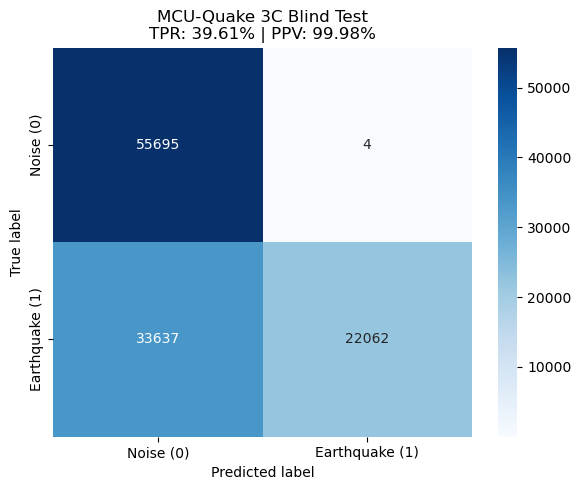

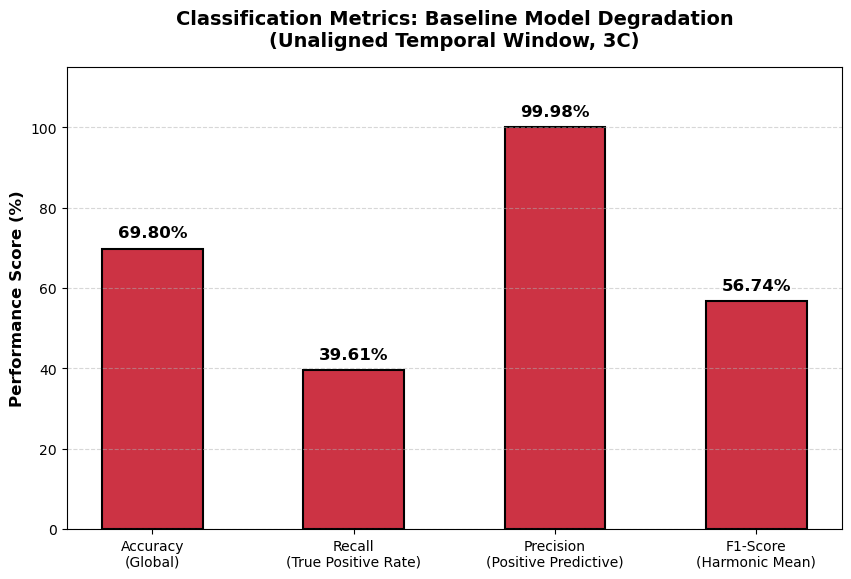

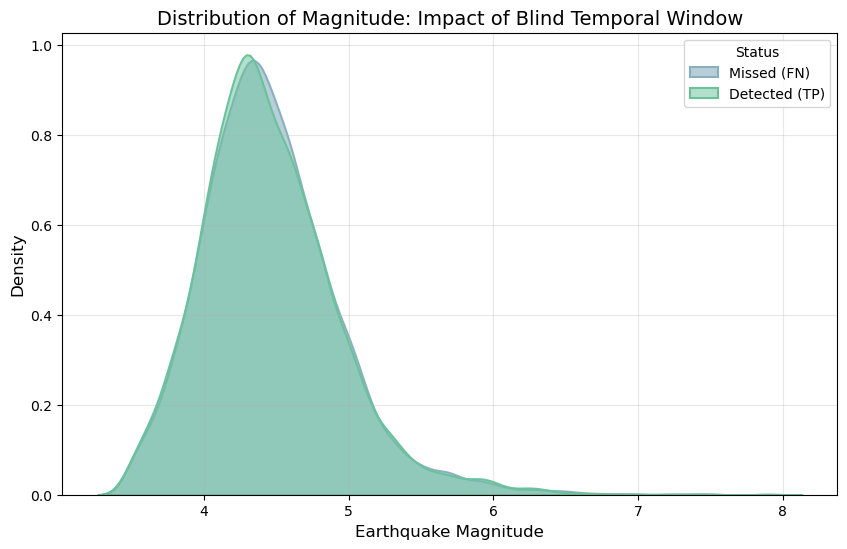

📝 Laporan CSV sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Library/mcu_quake_indonesia_true_3c_WITHOUT_TAUP_report.csv


In [5]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Library'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)

try:
    from Library import utils, dataset
except ImportError:
    print("❌ Library tidak ditemukan. Pastikan path benar.")
    sys.exit()

# ==============================================================================
# FUNGSI PENDUKUNG & VISUALISASI
# ==============================================================================
def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def visualisasi_confusion_matrix(y_true, y_pred, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Noise (0)', 'Earthquake (1)'], 
                yticklabels=['Noise (0)', 'Earthquake (1)'])
    plt.title(f'MCU-Quake 3C Blind Test\nTPR: {tpr*100:.2f}% | PPV: {ppv*100:.2f}%')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'vulnerability_test_cm.png'), dpi=300)
    plt.show()
    plt.close()

def visualisasi_bar_metrics(y_true, y_pred, output_dir):
    acc = accuracy_score(y_true, y_pred) * 100
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    precision = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics = [acc, recall, precision, f1]
    labels = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, metrics, color='#CC3344', edgecolor='black', width=0.5, linewidth=1.5)
    plt.ylim(0, 115) 
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.title('Classification Metrics: Baseline Model Degradation\n(Unaligned Temporal Window, 3C)', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Performance Score (%)', fontweight='bold', fontsize=12)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
        
    plt.savefig(os.path.join(output_dir, 'metrics_bar_chart.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def visualisasi_magnitude_kde(mag_detected, mag_missed, output_dir):
    if not mag_detected and not mag_missed:
        print("   ⚠️ Data magnitudo kosong, melewatkan plot KDE.")
        return
        
    plt.figure(figsize=(10, 6))
    if mag_missed:
        sns.kdeplot(mag_missed, fill=True, color='#8AB0C0', alpha=0.6, label='Missed (FN)', linewidth=1.5)
    if mag_detected:
        sns.kdeplot(mag_detected, fill=True, color='#69C29A', alpha=0.5, label='Detected (TP)', linewidth=1.5)
        
    plt.title('Distribution of Magnitude: Impact of Blind Temporal Window', fontsize=14)
    plt.xlabel('Earthquake Magnitude', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='-', alpha=0.3)
    plt.legend(title='Status', loc='upper right')
    
    plt.savefig(os.path.join(output_dir, 'magnitude_kde_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==============================================================================
# MAIN LOGIC
# ==============================================================================
def jalankan_stress_test_tanpa_taup():
    print("\n🚀 STARTING: ADVERSARIAL STRESS-TEST (BLIND ORIGIN TIME)")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    col_mag = next((c for c in df_catalog.columns if 'mag' in c), 'mag')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3: daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    y_true_list, y_pred_list, report_rows = [], [], []
    mag_detected, mag_missed = [], []

    for item in tqdm(daftar_file_mseed, desc="Processing"):
        try:
            st = read(item['path'])
            st.detrend("demean"); st.detrend("linear"); st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") or st.select(component="1")
            comp_e = st.select(component="E") or st.select(component="2")
            if not (comp_z and comp_n and comp_e): continue
            
            # Ambil Magnitudo untuk event ini
            mag_val = np.nan
            row_ev = df_catalog[df_catalog[col_id] == item['eid']]
            if not row_ev.empty and col_mag in row_ev.columns:
                try:
                    mag_val = float(row_ev.iloc[0][col_mag])
                except ValueError:
                    pass
            
            # Ekstraksi LE (Earthquake window kaku)
            idx_start = int(60.0 * 100)
            le_z, le_n, le_e = [bersihkan_dan_standardisasi_array(c[0].data[idx_start:idx_start+INPUT_SIZE]) for c in [comp_z, comp_n, comp_e]]
            
            emb_le = np.array([utils.latent_codes_1D(le_z, embedding_model),
                               utils.latent_codes_1D(le_n, embedding_model),
                               utils.latent_codes_1D(le_e, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le, embeddings_3C_PDFs, "Kernel")
            pred_le_biner = 1 if p_le == 0 else 0
            
            # Ekstraksi NO (Noise window)
            idx_n = int(10.0 * 100)
            no_z, no_n, no_e = [bersihkan_dan_standardisasi_array(c[0].data[idx_n:idx_n+INPUT_SIZE]) for c in [comp_z, comp_n, comp_e]]
            
            emb_no = np.array([utils.latent_codes_1D(no_z, embedding_model),
                               utils.latent_codes_1D(no_n, embedding_model),
                               utils.latent_codes_1D(no_e, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no, embeddings_3C_PDFs, "Kernel")
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            # Simpan Magnitudo untuk KDE jika prediksi label asli LE (1)
            if not np.isnan(mag_val):
                if pred_le_biner == 1:
                    mag_detected.append(mag_val)
                else:
                    mag_missed.append(mag_val)
            
            report_rows.append({'File': item['eid'], 'Type': 'LE', 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO', 'Decision': pred_no_biner})
        except Exception: continue

    print("\n📊 HASIL ANALISIS:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    
    # Render semua visualisasi
    output_directory = os.path.dirname(PATH_FINAL_REPORT)
    print("\n🎨 Menyusun Visualisasi Disertasi...")
    visualisasi_confusion_matrix(y_true_list, y_pred_list, output_directory)
    visualisasi_bar_metrics(y_true_list, y_pred_list, output_directory)
    visualisasi_magnitude_kde(mag_detected, mag_missed, output_directory)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan CSV sukses dikunci di -> {PATH_FINAL_REPORT}")
    
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_tanpa_taup()

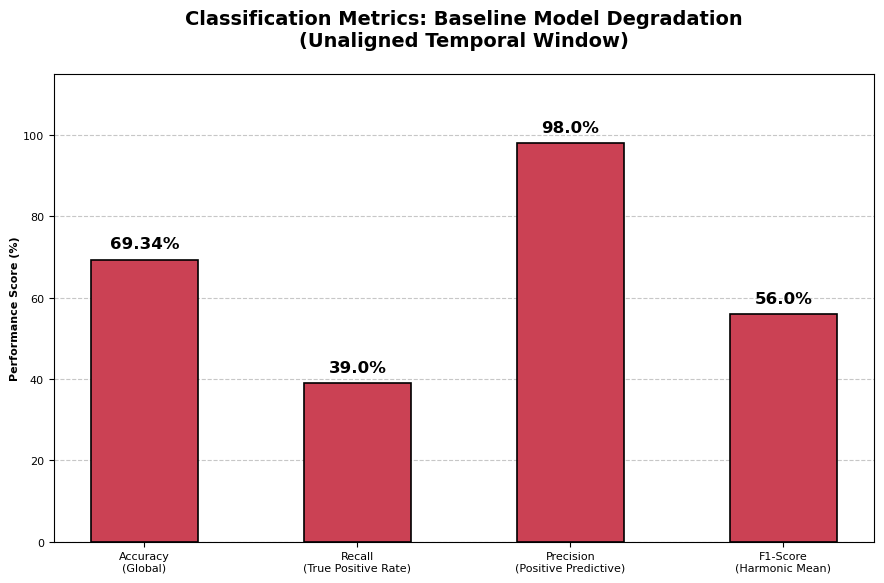

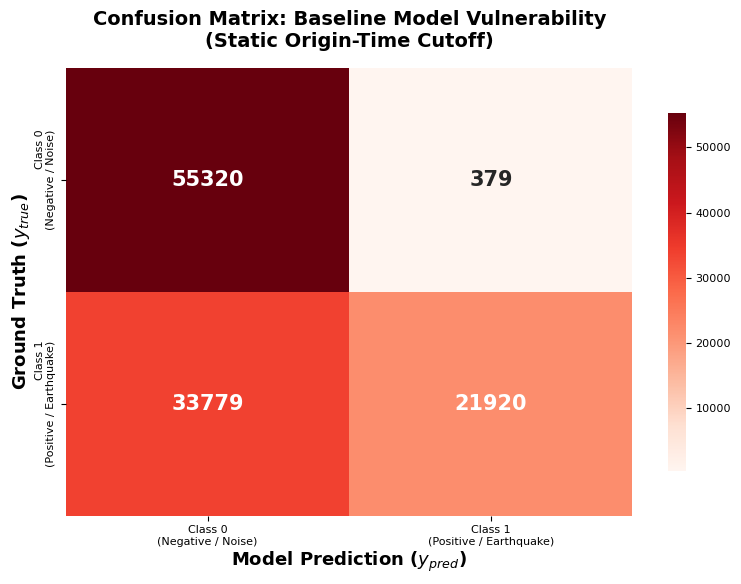


✅ Visualisasi bergaya Data Science / Machine Learning telah berhasil dirender!
💾 Grafik Metrik tersimpan di : /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/ML_Metrics_Baseline_No_TauP.jpg
💾 Grafik Matriks tersimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/Confusion_Matrix_Baseline_No_TauP.jpg


In [4]:

# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI PENYIMPANAN
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_BAR_PATH = os.path.join(PATH_DEMO_DIR, 'ML_Metrics_Baseline_No_TauP.jpg')
OUTPUT_CM_PATH = os.path.join(PATH_DEMO_DIR, 'Confusion_Matrix_Baseline_No_TauP.jpg')

# Memastikan folder tujuan tersedia
os.makedirs(PATH_DEMO_DIR, exist_ok=True)

# Pengaturan ukuran huruf standar untuk publikasi IEEE / ACM
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==============================================================================
# 📊 1. VISUALISASI METRIK KLASIFIKASI (BAR CHART)
# ==============================================================================
# Leksikon Machine Learning untuk label sumbu X
labels_metrics = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
scores_no_taup = [69.34, 39.0, 98.0, 56.0]

fig1, ax1 = plt.subplots(figsize=(9, 6))

# Warna merah bata (brick red) untuk merepresentasikan kelemahan/degradasi model
bars = ax1.bar(labels_metrics, scores_no_taup, color='#cb4154', width=0.5, edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Performance Score (%)', fontweight='bold')
ax1.set_title('Classification Metrics: Baseline Model Degradation\n(Unaligned Temporal Window)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0, 115) 

# Anotasi nilai persentase di atas batang grafik
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Mengatur grid latar belakang (gaya paper IT)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

fig1.tight_layout()
plt.savefig(OUTPUT_BAR_PATH, dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 📊 2. VISUALISASI CONFUSION MATRIX (HEATMAP)
# ==============================================================================
cm_no_taup = np.array([[55320, 379], 
                       [33779, 21920]])

# Leksikon Biner Klasifikasi AI
labels_cm = ['Class 0\n(Negative / Noise)', 'Class 1\n(Positive / Earthquake)']

fig2, ax2 = plt.subplots(figsize=(8, 6))

# Merender Heatmap (Peta Panas)
sns.heatmap(cm_no_taup, annot=True, fmt='d', cmap='Reds', ax=ax2, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax2.set_title('Confusion Matrix: Baseline Model Vulnerability\n(Static Origin-Time Cutoff)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

fig2.tight_layout()
plt.savefig(OUTPUT_CM_PATH, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*90)
print("✅ Visualisasi bergaya Data Science / Machine Learning telah berhasil dirender!")
print(f"💾 Grafik Metrik tersimpan di : {OUTPUT_BAR_PATH}")
print(f"💾 Grafik Matriks tersimpan di: {OUTPUT_CM_PATH}")
print("="*90)

In [6]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# PARAMETER DIREKTORI
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Library'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)

try:
    from Library import utils, dataset
    print("="*90)
    print("✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError:
    print("❌ Gagal memuat Library. Pastikan path benar.")
    sys.exit()

# ==============================================================================
# FUNGSI PENDUKUNG
# ==============================================================================
def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def visualisasi_evaluasi(y_true, y_pred, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Noise (0)', 'Earthquake (1)'], 
                yticklabels=['Noise (0)', 'Earthquake (1)'])
    plt.title('Confusion Matrix: Blind Temporal Inference')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    save_path = os.path.join(output_dir, 'confusion_matrix_vulnerability.png')
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"\n   📊 Visualisasi Confusion Matrix tersimpan di -> {save_path}")

# ==============================================================================
# MAIN LOGIC
# ==============================================================================
def jalankan_stress_test_tanpa_taup():
    print("\n🚀 STARTING: ADVERSARIAL STRESS-TEST (WITHOUT TAUP)")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3: daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    y_true_list, y_pred_list, report_rows = [], [], []

    for item in tqdm(daftar_file_mseed, desc="Processing Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean"); st.detrend("linear"); st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z"); comp_n = st.select(component="N") or st.select(component="1")
            comp_e = st.select(component="E") or st.select(component="2")
            if not (comp_z and comp_n and comp_e): continue
            
            # Extract 60 detik (Origin Time)
            idx_start = int(60.0 * 100)
            idx_end = idx_start + INPUT_SIZE
            le_z, le_n, le_e = [bersihkan_dan_standardisasi_array(c[0].data[idx_start:idx_end]) for c in [comp_z, comp_n, comp_e]]
            
            emb = np.array([utils.latent_codes_1D(le_z, embedding_model),
                            utils.latent_codes_1D(le_n, embedding_model),
                            utils.latent_codes_1D(le_e, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb, embeddings_3C_PDFs, "Kernel")
            
            # Noise (10 detik awal)
            no_z, no_n, no_e = [bersihkan_dan_standardisasi_array(c[0].data[1000:1000+INPUT_SIZE]) for c in [comp_z, comp_n, comp_e]]
            emb_no = np.array([utils.latent_codes_1D(no_z, embedding_model),
                               utils.latent_codes_1D(no_n, embedding_model),
                               utils.latent_codes_1D(no_e, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no, embeddings_3C_PDFs, "Kernel")
            
            y_true_list.extend([1, 0]); y_pred_list.extend([1 if p_le == 0 else 0, 1 if p_no == 0 else 0])
            report_rows.append({'File': item['eid'], 'Type': 'LE', 'Decision': (1 if p_le == 0 else 0)})
            report_rows.append({'File': item['eid'], 'Type': 'NO', 'Decision': (1 if p_no == 0 else 0)})
        except Exception: continue

    # Evaluasi & Visualisasi
    print("\n📊 HASIL VULNERABILITY TEST:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    visualisasi_evaluasi(y_true_list, y_pred_list, os.path.dirname(PATH_FINAL_REPORT))
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_tanpa_taup()

✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST (WITHOUT TAUP)


Processing Seismograms: 100%|██████████| 55699/55699 [28:27<00:00, 32.61it/s]



📊 HASIL VULNERABILITY TEST:
                precision    recall  f1-score   support

     Noise (0)       0.62      1.00      0.77     55699
Earthquake (1)       1.00      0.40      0.57     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398


   📊 Visualisasi Confusion Matrix tersimpan di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Library/confusion_matrix_vulnerability.png


In [4]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns # TAMBAHAN VISUALISASI
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (VULNERABILITY TEST)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

# FUNGSI TAMBAHAN VISUALISASI
def visualisasi_evaluasi(y_true, y_pred, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Noise (0)', 'Earthquake (1)'], 
                yticklabels=['Noise (0)', 'Earthquake (1)'])
    plt.title('Confusion Matrix: Blind Temporal Inference')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    save_path = os.path.join(output_dir, 'vulnerability_test_cm.png')
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"   📊 Visualisasi Confusion Matrix tersimpan di -> {save_path}")

def jalankan_stress_test_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 3C STEAD...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform siap diuji buta temporal.")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela kaku tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") if st.select(component="N") else st.select(component="1")
            comp_e = st.select(component="E") if st.select(component="E") else st.select(component="2")
            
            if not (comp_z and comp_n and comp_e): continue
            
            detik_origin_kaku = 60.0
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            le_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_le:idx_end_le])
            le_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_le:idx_end_le])
            
            emb_le_3c = np.array([utils.latent_codes_1D(le_z, embedding_model),
                                  utils.latent_codes_1D(le_n, embedding_model),
                                  utils.latent_codes_1D(le_e, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le_3c, embeddings_3C_PDFs, "Kernel")
            
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            no_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_no:idx_end_no])
            no_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_no:idx_end_no])
            
            emb_no_3c = np.array([utils.latent_codes_1D(no_z, embedding_model),
                                  utils.latent_codes_1D(no_n, embedding_model),
                                  utils.latent_codes_1D(no_e, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no_3c, embeddings_3C_PDFs, "Kernel")
            
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    print(f"🎯 AKURASI BUTA TEMPORAL (BLIND ORIGIN TIME) : {skor_akurasi * 100:.2f} %")
    print("-" * 107)
    print("📋 LAPORAN METRIK BUKTI KERENTANAN:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 107)
    print("📊 MATRIKS KEBINGUNGAN (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 107)
    
    # PEMANGGILAN VISUALISASI
    visualisasi_evaluasi(y_true_list, y_pred_list, os.path.dirname(PATH_FINAL_REPORT))
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan bukti kelemahan AI sukses dikunci di -> {PATH_FINAL_REPORT}\n")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_tanpa_taup()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (VULNERABILITY TEST)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
⏳ Memuat database statistik Typical Embeddings 3C STEAD...
   ✅ Sukses Mengunci: 55,699 berkas waveform siap diuji buta temporal.

⏳ Mengekstrak jendela kaku tepat di Origin Time (Tanpa TauP)...


Processing Unaligned Seismograms: 100%|██████████| 55699/55699 [31:21<00:00, 29.60it/s]



📊================================== VULNERABILITY TEST RESULTS (NO TAUP) ==================================
🎯 AKURASI BUTA TEMPORAL (BLIND ORIGIN TIME) : 69.80 %
-----------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK BUKTI KERENTANAN:
                precision    recall  f1-score   support

     Noise (0)       0.62      1.00      0.77     55699
Earthquake (1)       1.00      0.40      0.57     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398

-----------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN (CONFUSION MATRIX):
[[55695     4]
 [33637 22062]]
   📊 Visualisasi Confusion Matrix tersimpan di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Cod